# Extended Analyses

Self-contained notebook with the extended analyses for *"Projections of Earth's Technosphere: Civilization Collapse-Recovery Dynamics and Detectability"* (Acta Astronautica): summary statistics and collapse-cause attribution, Monte Carlo convergence, percentile-band trajectory figures, the simulation-horizon analysis with the asymptotic duty cycle, ON-threshold robustness, global sensitivity analysis (LHS + PRCC) and two-parameter collapse maps, and growth-law invariance and technology-coupling experiments.

Outputs: figures → `../figures/si/`, tables → `../tex/generated/`, key numbers → `../tex/generated/key_numbers.json`.

In [1]:
import json
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import rankdata

project_root = pathlib.Path.cwd().parent
fig_dir = project_root / "figures" / "si"
tab_dir = project_root / "tex" / "generated"
fig_dir.mkdir(parents=True, exist_ok=True)
tab_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 12,
    "axes.edgecolor": "black", "axes.facecolor": "white",
    "figure.facecolor": "white",
})

KEY = {}  # numbers cited in the manuscript / response letter

## 1. Model definition

The simulator below is identical to the one used in `figures.ipynb`
(`figures.ipynb`), with the same random-draw order, so that its results are exactly
reproduced when called with the same seed and default options. Optional
arguments (disabled by default) implement the extensions used in Sections 4–7:
arbitrary horizon, alternative growth laws, and technology coupling.

In [2]:
scenario_params = {
    "S1":  {"Name": "Big Brother is Watching", "r": 0.0020, "R0_mean": 400,  "delta_mean": 1.2,
            "cf_mean": 0.6, "rd_mean": 40,  "rf_mean": 0.15, "h_ex_risk": 0.003},
    "S2":  {"Name": "Wild West",               "r": 0.0026, "R0_mean": 700,  "delta_mean": 1.5,
            "cf_mean": 0.3, "rd_mean": 70,  "rf_mean": 0.10, "h_ex_risk": 0.001},
    "S3":  {"Name": "Golden Age",              "r": 0.0001, "R0_mean": 2400, "delta_mean": 0.0,
            "cf_mean": 1.0, "rd_mean": 0,   "rf_mean": 1.0,  "h_ex_risk": 0.0},
    "S4":  {"Name": "Living with the Land",    "r": 0.0060, "R0_mean": 600,  "delta_mean": 2.5,
            "cf_mean": 0.2, "rd_mean": 100, "rf_mean": 0.10, "h_ex_risk": 0.0},
    "S5":  {"Name": "Transhumanism",           "r": 0.0003, "R0_mean": 2500, "delta_mean": 0.1,
            "cf_mean": 0.9, "rd_mean": 20,  "rf_mean": 0.80, "h_ex_risk": 0.0005},
    "S6":  {"Name": "Sword of Damocles",       "r": 0.0018, "R0_mean": 1600, "delta_mean": 1.0,
            "cf_mean": 0.4, "rd_mean": 50,  "rf_mean": 0.25, "h_ex_risk": 0.005},
    "S7":  {"Name": "Restoration",             "r": 0.0060, "R0_mean": 400,  "delta_mean": 1.5,
            "cf_mean": 0.3, "rd_mean": 60,  "rf_mean": 0.20, "h_ex_risk": 0.001},
    "S8":  {"Name": "Ouroboros",               "r": 0.0015, "R0_mean": 800,  "delta_mean": 1.3,
            "cf_mean": 0.6, "rd_mean": 70,  "rf_mean": 0.35, "h_ex_risk": 0.0},
    "S9":  {"Name": "Deus Ex Machina",         "r": 0.0011, "R0_mean": 900,  "delta_mean": 1.3,
            "cf_mean": 0.5, "rd_mean": 70,  "rf_mean": 0.35, "h_ex_risk": 0.0},
    "S10": {"Name": "Out of Eden",             "r": 0.0002, "R0_mean": 2700, "delta_mean": 0.0,
            "cf_mean": 1.0, "rd_mean": 0,   "rf_mean": 1.0,  "h_ex_risk": 0.0},
}
SCEN = list(scenario_params)
COLLAPSE_PRONE = ["S1", "S2", "S4", "S6", "S7", "S8", "S9"]

# Monte Carlo uncertainty settings (as in figures.ipynb).
# All sampled parameters are truncated to their physically admissible ranges:
# R0 >= 1, delta >= 0, rd >= 0, and cf, rf clipped to [0, 1].
frac_R0, frac_delta, frac_cf, std_rd, frac_rf = 0.05, 0.05, 0.05, 10, 0.05
LIFESPAN = 1000


def safe_triangular(rng, center, frac, min_val=0, max_val=1):
    """Triangular sampling truncated to [min_val, max_val]."""
    if frac == 0:
        return center
    left = max(min_val, center * (1 - frac))
    right = min(max_val, center * (1 + frac))
    if np.isclose(left, right):
        return center
    return np.clip(rng.triangular(left, center, right), min_val, max_val)


def sample_params(p, rng):
    """Draw one Monte Carlo parameter set (same draw order as figures.ipynb)."""
    R0 = max(1.0, rng.normal(p["R0_mean"], frac_R0 * p["R0_mean"])) if frac_R0 > 0 else p["R0_mean"]
    delta = max(0.0, rng.normal(p["delta_mean"], frac_delta * p["delta_mean"])) if frac_delta > 0 else p["delta_mean"]
    cf = safe_triangular(rng, p["cf_mean"], frac_cf)
    rf = safe_triangular(rng, p["rf_mean"], frac_rf)
    rd = max(0, rng.normal(p["rd_mean"], std_rd)) if std_rd > 0 else p["rd_mean"]
    return R0, delta, cf, rd, rf


def simulate(r, R0, delta, cf, rd, rf, h, rng, lifespan=LIFESPAN, growth="linear",
             K=5.0, gamma_delta=0.0, gamma_rf=0.0, record=True):
    """Single-run simulator.

    Defaults reproduce the baseline model exactly (identical RNG draw order).
    Extensions:
      growth      : 'linear' (baseline), 'exponential', or 'logistic' growth of T
      gamma_delta : technology-efficiency coupling, delta_eff = delta / (1 + gamma_delta (T - 1))
      gamma_rf    : technology-recovery coupling, rf_eff = min(1, rf (1 + gamma_rf (T - 1)))
    Returns (tech_ts, res_ts, first_collapse, n_cycles, duty_cycle, n_hazard) where
    n_hazard counts hazard-triggered (as opposed to depletion-triggered) collapses.
    """
    T, R = 1.0, R0
    in_collapse, timer = False, 0
    tech_ts = np.empty(lifespan, dtype=np.float32) if record else None
    res_ts = np.empty(lifespan, dtype=np.float32) if record else None
    collapse_events, n_hazard = [], 0
    active_years = 0
    first_collapse = lifespan

    for t in range(lifespan):
        if in_collapse:
            timer += 1
            if timer >= rd:
                rf_eff = min(1.0, rf * (1 + gamma_rf * (T - 1))) if gamma_rf > 0 else rf
                R = R0 * rf_eff
                in_collapse = False
                timer = 0
        else:
            if growth == "linear":
                T += r
            elif growth == "exponential":
                T *= (1 + r)
            elif growth == "logistic":
                T += r * (K / (K - 1)) * T * (1 - T / K)
            delta_eff = delta / (1 + gamma_delta * (T - 1)) if gamma_delta > 0 else delta
            R -= delta_eff
            hazard_hit = rng.random() < h
            if hazard_hit:
                R = 0
            if R <= 0:
                R = 0
                in_collapse = True
                timer = 0
                T *= cf
                if not collapse_events:
                    first_collapse = t
                collapse_events.append(t)
                if hazard_hit:
                    n_hazard += 1
        if record:
            tech_ts[t] = T
            res_ts[t] = R
        if R > 0:
            active_years += 1

    duty_cycle = active_years / lifespan
    return tech_ts, res_ts, first_collapse, len(collapse_events), duty_cycle, n_hazard


def run_mc(replicates, seed=12345, lifespan=LIFESPAN, record=False, **sim_kwargs):
    """Monte Carlo sweep over all scenarios; returns metrics dict (and curves if record)."""
    rng = np.random.default_rng(seed)
    metrics = {}
    tech_curves, res_curves = {}, {}
    for s, p in scenario_params.items():
        Ls, Cs, Ds, Hs = [], [], [], []
        t_runs, r_runs = [], []
        for _ in range(replicates):
            R0, delta, cf, rd, rf = sample_params(p, rng)
            tech, res, L, C, D, H = simulate(p["r"], R0, delta, cf, rd, rf, p["h_ex_risk"],
                                             rng, lifespan=lifespan, record=record, **sim_kwargs)
            Ls.append(L); Cs.append(C); Ds.append(D); Hs.append(H)
            if record:
                t_runs.append(tech); r_runs.append(res)
        metrics[s] = {"Tc": np.array(Ls, float), "Nc": np.array(Cs, float),
                      "Dc": np.array(Ds, float), "Nh": np.array(Hs, float)}
        if record:
            tech_curves[s] = np.vstack(t_runs)
            res_curves[s] = np.vstack(r_runs)
    return (metrics, tech_curves, res_curves) if record else metrics

## 2. Baseline and summary statistics

We first verify that the code reproduces the baseline results of `figures.ipynb` (200 replicates,
seed 12345), then compute the full summary statistics, reporting means,
standard deviations, and 95% confidence intervals for all four metrics, together with
the attribution of collapses to external hazards vs internal resource depletion.

In [3]:
m200 = run_mc(200, seed=12345)
rows = []
for s in SCEN:
    m = m200[s]
    rows.append({"Scenario": s, "Mean_Collapse": m["Tc"].mean(),
                 "Never_Collapsed_Frac": (m["Tc"] == LIFESPAN).mean(),
                 "Mean_Duty_Cycle": m["Dc"].mean(), "Mean_Cycles": m["Nc"].mean()})
print("Reproduction of baseline (200 replicates, seed 12345):")
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x: f"{x:.3f}"))

Reproduction of submitted baseline (200 replicates, seed 12345):
Scenario  Mean_Collapse  Never_Collapsed_Frac  Mean_Duty_Cycle  Mean_Cycles
      S1        205.840                 0.000            0.623        9.755
      S2        383.215                 0.000            0.614        5.840
      S3       1000.000                 1.000            1.000        0.000
      S4        240.625                 0.000            0.381        6.600
      S5        810.590                 0.635            0.991        0.450
      S6        169.480                 0.000            0.785        4.460
      S7        223.320                 0.000            0.572        7.470
      S8        623.480                 0.000            0.875        1.935
      S9        689.240                 0.000            0.910        1.520
     S10       1000.000                 1.000            1.000        0.000


In [4]:
N_BASE = 200
mbase, tech_curves, res_curves = run_mc(N_BASE, seed=12345, record=True)

rows = []
for s in SCEN:
    m = mbase[s]
    n = N_BASE
    fnc = (m["Tc"] == LIFESPAN).mean()
    fnc_se = np.sqrt(fnc * (1 - fnc) / n)
    n_collapses = m["Nc"].sum()
    haz_frac = m["Nh"].sum() / n_collapses if n_collapses > 0 else np.nan
    rows.append({
        "Scenario": s, "Name": scenario_params[s]["Name"],
        "Dc_mean": m["Dc"].mean(), "Dc_std": m["Dc"].std(),
        "Dc_ci95": 1.96 * m["Dc"].std() / np.sqrt(n),
        "Tc_mean": m["Tc"].mean(), "Tc_std": m["Tc"].std(),
        "Tc_ci95": 1.96 * m["Tc"].std() / np.sqrt(n),
        "Nc_mean": m["Nc"].mean(), "Nc_std": m["Nc"].std(),
        "Nc_ci95": 1.96 * m["Nc"].std() / np.sqrt(n),
        "fnc": fnc, "fnc_ci95": 1.96 * fnc_se,
        "hazard_frac": haz_frac,
    })
summary = pd.DataFrame(rows)
summary.to_csv(tab_dir / "summary_stats.csv", index=False)
print(f"Baseline ({N_BASE} replicates):")
print(summary.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

Revised baseline (200 replicates):
Scenario                    Name  Dc_mean  Dc_std  Dc_ci95  Tc_mean  Tc_std  Tc_ci95  Nc_mean  Nc_std  Nc_ci95   fnc  fnc_ci95  hazard_frac
      S1 Big Brother is Watching    0.623   0.078    0.011  205.840 124.068   17.195    9.755   1.927    0.267 0.000     0.000        0.202
      S2               Wild West    0.614   0.094    0.013  383.215 148.492   20.580    5.840   1.369    0.190 0.000     0.000        0.097
      S3              Golden Age    1.000   0.000    0.000 1000.000   0.000    0.000    0.000   0.000    0.000 1.000     0.000          NaN
      S4    Living with the Land    0.381   0.025    0.003  240.625  17.213    2.386    6.600   0.616    0.085 0.000     0.000        0.000
      S5           Transhumanism    0.991   0.015    0.002  810.590 299.296   41.480    0.450   0.676    0.094 0.635     0.067        1.000
      S6       Sword of Damocles    0.785   0.070    0.010  169.480 156.792   21.730    4.460   1.371    0.190 0.000     0.00

In [5]:
# LaTeX table for the manuscript (Results section)
def fmt(mean, sd, ci, dec=2):
    return f"${mean:.{dec}f} \\pm {sd:.{dec}f}$ & $\\pm{ci:.{dec}f}$"

lines = [
    "% Auto-generated by si_analysis.ipynb -- do not edit by hand",
    "\\begin{table*}[htbp]",
    "\\centering",
    "\\caption{Summary statistics of the four outcome metrics across scenarios "
    f"({N_BASE} Monte Carlo replicates). For each metric we report the ensemble mean $\\pm$ "
    "one standard deviation and the half-width of the 95\\% confidence interval of the mean "
    "(for $f_{nc}$, a binomial standard-error interval). The last column gives the fraction "
    "of collapse events triggered by the stochastic external hazard, the remainder being "
    "triggered by internal resource depletion.}",
    "\\label{tab:summary-stats}",
    "\\small",
    "\\begin{tabular}{l c c c c c c c c c}",
    "\\toprule",
    " & \\multicolumn{2}{c}{$D_c$} & \\multicolumn{2}{c}{$T_c$ (yr)} & "
    "\\multicolumn{2}{c}{$N_c$} & \\multicolumn{2}{c}{$f_{nc}$} & Hazard \\\\",
    "\\cmidrule(lr){2-3} \\cmidrule(lr){4-5} \\cmidrule(lr){6-7} \\cmidrule(lr){8-9}",
    "Scenario & mean $\\pm$ sd & CI$_{95}$ & mean $\\pm$ sd & CI$_{95}$ & "
    "mean $\\pm$ sd & CI$_{95}$ & value & CI$_{95}$ & frac. \\\\",
    "\\midrule",
]
for _, r0 in summary.iterrows():
    hf = "--" if np.isnan(r0["hazard_frac"]) else f"{r0['hazard_frac']:.2f}"
    lines.append(
        f"{r0['Scenario']} & {fmt(r0['Dc_mean'], r0['Dc_std'], r0['Dc_ci95'])} & "
        f"{fmt(r0['Tc_mean'], r0['Tc_std'], r0['Tc_ci95'], 0)} & "
        f"{fmt(r0['Nc_mean'], r0['Nc_std'], r0['Nc_ci95'])} & "
        f"${r0['fnc']:.2f}$ & $\\pm{r0['fnc_ci95']:.2f}$ & {hf} \\\\"
    )
lines += ["\\bottomrule", "\\end{tabular}", "\\end{table*}", ""]
(tab_dir / "table_summary_stats.tex").write_text("\n".join(lines))
print((tab_dir / "table_summary_stats.tex").read_text())

for s in SCEN:
    KEY[f"{s}_Dc"] = round(float(summary.set_index("Scenario").loc[s, "Dc_mean"]), 3)
    KEY[f"{s}_Tc"] = round(float(summary.set_index("Scenario").loc[s, "Tc_mean"]), 1)
    KEY[f"{s}_Nc"] = round(float(summary.set_index("Scenario").loc[s, "Nc_mean"]), 2)
    KEY[f"{s}_fnc"] = round(float(summary.set_index("Scenario").loc[s, "fnc"]), 3)
    hf = summary.set_index("Scenario").loc[s, "hazard_frac"]
    KEY[f"{s}_hazardfrac"] = None if np.isnan(hf) else round(float(hf), 3)

% Auto-generated by revision_analysis.ipynb -- do not edit by hand
\begin{table*}[htbp]
\centering
\color{red}  % new table added in revision
\caption{Summary statistics of the four outcome metrics across scenarios (200 Monte Carlo replicates). For each metric we report the ensemble mean $\pm$ one standard deviation and the half-width of the 95\% confidence interval of the mean (for $f_{nc}$, a binomial standard-error interval). The last column gives the fraction of collapse events triggered by the stochastic external hazard, the remainder being triggered by internal resource depletion.}
\label{tab:summary-stats}
\small
\begin{tabular}{l c c c c c c c c c}
\toprule
 & \multicolumn{2}{c}{$D_c$} & \multicolumn{2}{c}{$T_c$ (yr)} & \multicolumn{2}{c}{$N_c$} & \multicolumn{2}{c}{$f_{nc}$} & Hazard \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} \cmidrule(lr){6-7} \cmidrule(lr){8-9}
Scenario & mean $\pm$ sd & CI$_{95}$ & mean $\pm$ sd & CI$_{95}$ & mean $\pm$ sd & CI$_{95}$ & value & CI$_{95}$ & fr

## 3. Monte Carlo convergence analysis

Cumulative estimates of each metric as a function of the number of replicates, for a
single long run of 2000 replicates per scenario (independent seed). We also report the
relative deviation of the N = 200 estimate from the N = 2000 estimate, and the Monte
Carlo standard error at N = 200.

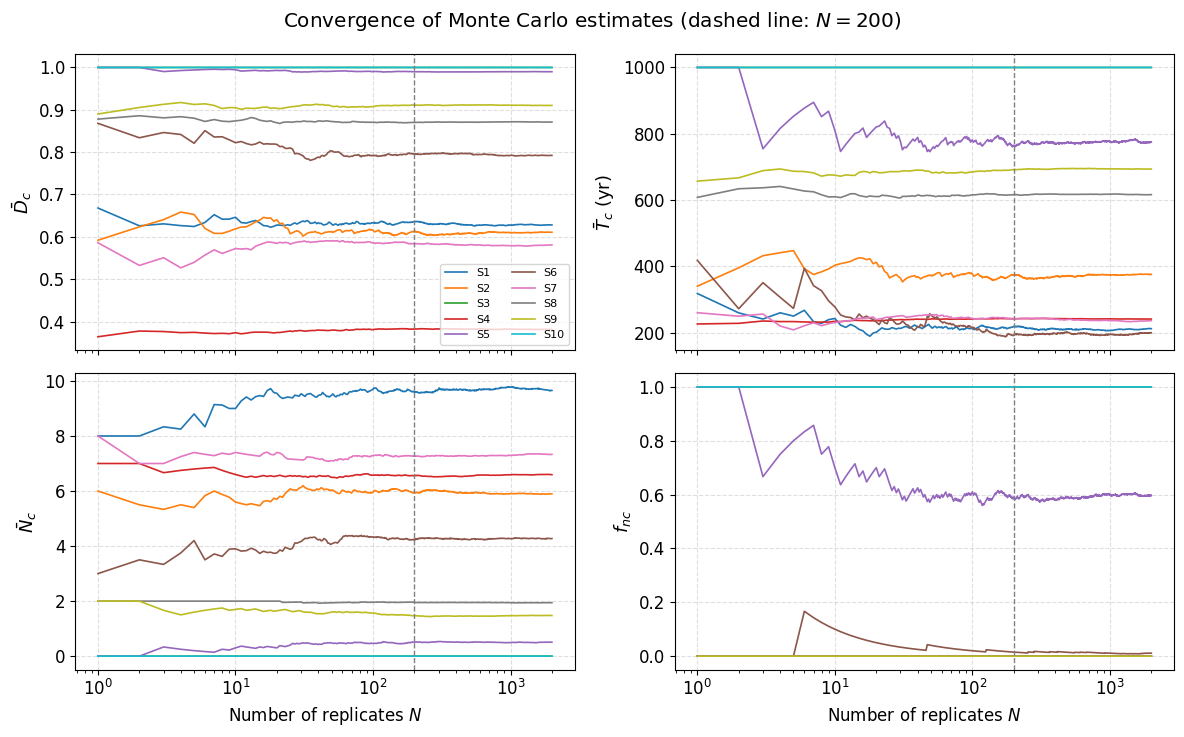

Max relative deviation of N=200 estimate from N=2000 estimate, by metric:
Metric
Dc    0.012
Nc    0.009
Tc    0.036
fnc   0.364


In [6]:
N_CONV = 2000
mconv = run_mc(N_CONV, seed=777)

metric_defs = {
    "Dc": (r"$\bar{D}_c$", lambda m: m["Dc"]),
    "Tc": (r"$\bar{T}_c$ (yr)", lambda m: m["Tc"]),
    "Nc": (r"$\bar{N}_c$", lambda m: m["Nc"]),
    "fnc": (r"$f_{nc}$", lambda m: (m["Tc"] == LIFESPAN).astype(float)),
}

fig, axs = plt.subplots(2, 2, figsize=(12, 7.5), sharex=True)
axs = axs.flatten()
Ns = np.arange(1, N_CONV + 1)
conv_rows = []
for ax, (key, (label, getter)) in zip(axs, metric_defs.items()):
    for s in SCEN:
        x = getter(mconv[s])
        cum = np.cumsum(x) / Ns
        ax.plot(Ns, cum, lw=1.2, label=s)
    ax.axvline(N_BASE, color="gray", ls="--", lw=1)
    ax.set_xscale("log")
    ax.set_ylabel(label, fontsize=13)
    ax.grid(True, ls="--", alpha=0.4)
for s in SCEN:
    for key, (_, getter) in metric_defs.items():
        x = getter(mconv[s])
        est200, est2000 = x[:200].mean(), x.mean()
        se200 = x[:200].std() / np.sqrt(200)
        denom = abs(est2000) if abs(est2000) > 1e-12 else np.nan
        conv_rows.append({"Scenario": s, "Metric": key, "est_200": est200,
                          "est_2000": est2000, "rel_dev_200": abs(est200 - est2000) / denom,
                          "se_200": se200})
axs[2].set_xlabel("Number of replicates $N$")
axs[3].set_xlabel("Number of replicates $N$")
axs[0].legend(fontsize=8, ncol=2, loc="lower right")
fig.suptitle(f"Convergence of Monte Carlo estimates (dashed line: $N={N_BASE}$)")
plt.tight_layout()
plt.savefig(fig_dir / "figureB_convergence.png", dpi=300, bbox_inches="tight")
plt.show()

conv_df = pd.DataFrame(conv_rows)
conv_df.to_csv(tab_dir / "convergence.csv", index=False)
worst = conv_df.dropna(subset=["rel_dev_200"])
print("Max relative deviation of N=200 estimate from N=2000 estimate, by metric:")
print(worst.groupby("Metric")["rel_dev_200"].max().to_string(float_format=lambda x: f"{x:.3f}"))
KEY["conv_max_rel_dev_200"] = round(float(worst["rel_dev_200"].max()), 4)
KEY["conv_max_rel_dev_Dc_200"] = round(float(worst[worst.Metric == "Dc"]["rel_dev_200"].max()), 4)
KEY["conv_max_se_Dc_200"] = round(float(conv_df[conv_df.Metric == "Dc"]["se_200"].max()), 4)

## 4. Percentile-band Figure 1 and per-scenario trajectory grid

Main-text Figure 1: median trajectories with P5–P95 percentile bands (the mean
is retained as a dashed line). Appendix figure: per-scenario panels showing individual
resource trajectories, which display the abrupt collapse events that ensemble averages
smooth out.

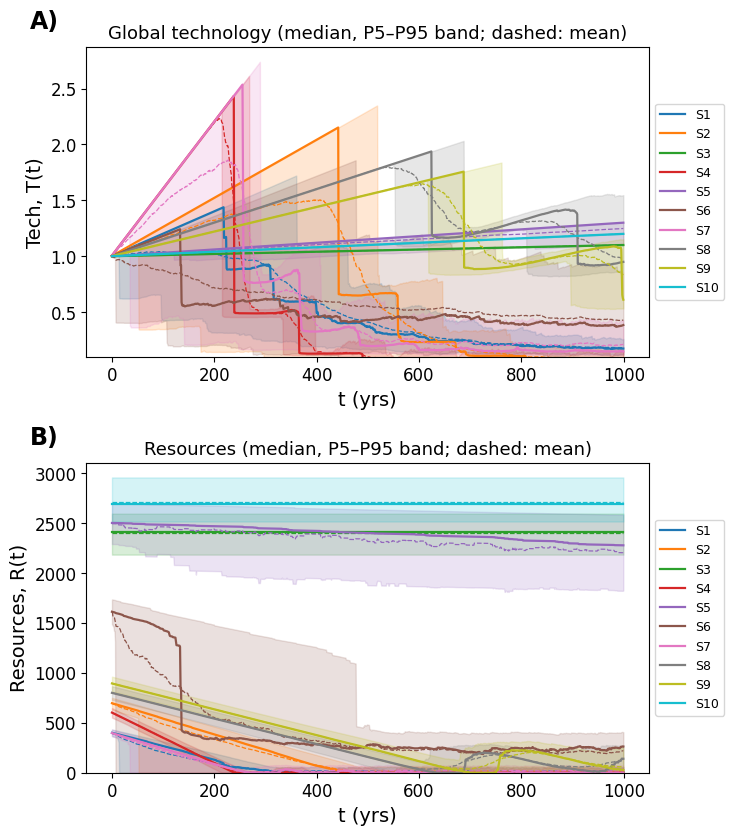

In [7]:
ticks = np.arange(LIFESPAN)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7.5, 8.5))
for ax, curves, ylab, title in [
    (ax1, tech_curves, "Tech, T(t)", "Global technology"),
    (ax2, res_curves, "Resources, R(t)", "Resources"),
]:
    for s in SCEN:
        arr = curves[s]
        med = np.median(arr, axis=0)
        p5, p95 = np.percentile(arr, [5, 95], axis=0)
        line, = ax.plot(ticks, med, lw=1.6, label=s)
        ax.fill_between(ticks, p5, p95, alpha=0.18, color=line.get_color())
        ax.plot(ticks, arr.mean(axis=0), lw=0.9, ls="--", color=line.get_color())
    ax.set_xlabel("t (yrs)", fontsize=14)
    ax.set_ylabel(ylab, fontsize=14)
    ax.set_title(f"{title} (median, P5–P95 band; dashed: mean)", fontsize=13)
    ax.legend(fontsize=9, loc="center left", bbox_to_anchor=(1, 0.5))
    ax.set_ylim(bottom=0)
ax1.set_ylim(bottom=0.1)
ax1.text(-0.1, 1.12, "A)", transform=ax1.transAxes, fontsize=17, fontweight="bold", va="top")
ax2.text(-0.1, 1.12, "B)", transform=ax2.transAxes, fontsize=17, fontweight="bold", va="top")
plt.tight_layout()
plt.savefig(fig_dir / "figure1.png", dpi=300, bbox_inches="tight")
plt.show()

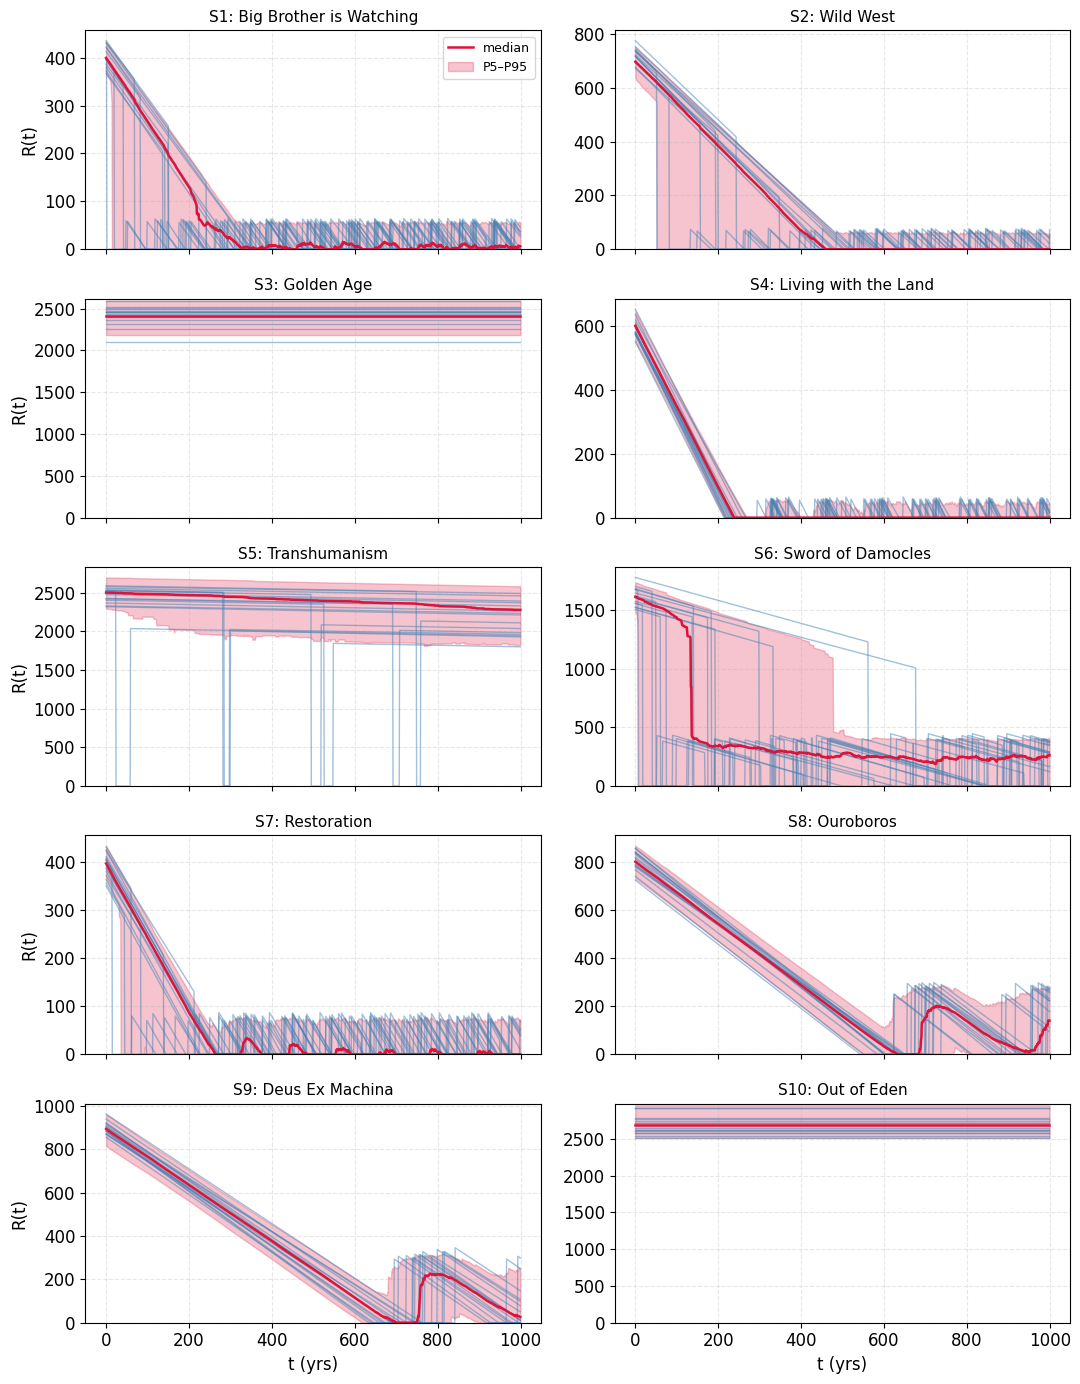

In [8]:
fig, axs = plt.subplots(5, 2, figsize=(11, 14), sharex=True)
axs = axs.flatten()
rng_pick = np.random.default_rng(3)
for ax, s in zip(axs, SCEN):
    arr = res_curves[s]
    idx = rng_pick.choice(arr.shape[0], size=15, replace=False)
    for i in idx:
        ax.plot(ticks, arr[i], lw=1.0, alpha=0.5, color="steelblue")
    med = np.median(arr, axis=0)
    p5, p95 = np.percentile(arr, [5, 95], axis=0)
    ax.plot(ticks, med, lw=1.8, color="crimson", label="median")
    ax.fill_between(ticks, p5, p95, alpha=0.25, color="crimson", label="P5–P95")
    ax.set_title(f"{s}: {scenario_params[s]['Name']}", fontsize=11)
    ax.set_ylim(bottom=0)
    ax.grid(True, ls="--", alpha=0.3)
axs[0].legend(fontsize=9)
for ax in axs[-2:]:
    ax.set_xlabel("t (yrs)")
for i in range(0, 10, 2):
    axs[i].set_ylabel("R(t)")
plt.tight_layout()
plt.savefig(fig_dir / "figureA_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Simulation-horizon analysis

Duty cycle (and collapse counts per 1000 yr) when the simulation horizon is extended to
3,000 and 10,000 yr. For the collapse-prone scenarios the dynamics are cyclic, so the
duty cycle is approximately stationary in the horizon length; horizon dependence is
confined to scenarios whose first collapse would occur beyond 1000 yr.

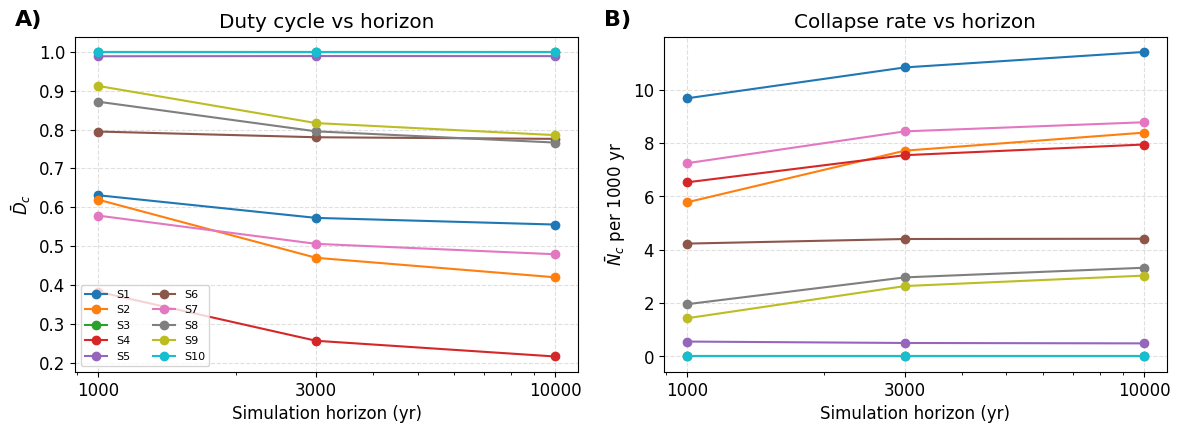

Horizon   1000   3000   10000
Scenario                     
S1        0.631  0.573  0.555
S2        0.620  0.470  0.420
S3        1.000  1.000  1.000
S4        0.382  0.256  0.215
S5        0.989  0.989  0.989
S6        0.795  0.780  0.776
S7        0.578  0.506  0.479
S8        0.872  0.795  0.767
S9        0.913  0.817  0.786
S10       1.000  1.000  1.000


In [9]:
horizons = [1000, 3000, 10000]
N_HOR = 300
hor_rows = []
for lh in horizons:
    mh = run_mc(N_HOR, seed=2024, lifespan=lh)
    for s in SCEN:
        m = mh[s]
        hor_rows.append({"Horizon": lh, "Scenario": s, "Dc": m["Dc"].mean(),
                         "Dc_std": m["Dc"].std(), "Nc_per_kyr": m["Nc"].mean() / (lh / 1000),
                         "fnc": (m["Tc"] == lh).mean()})
hor_df = pd.DataFrame(hor_rows)
hor_df.to_csv(tab_dir / "horizon.csv", index=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for s in SCEN:
    d = hor_df[hor_df.Scenario == s]
    ax1.plot(d["Horizon"], d["Dc"], marker="o", label=s)
    ax2.plot(d["Horizon"], d["Nc_per_kyr"], marker="o", label=s)
ax1.set_xscale("log"); ax2.set_xscale("log")
ax1.set_xlabel("Simulation horizon (yr)"); ax2.set_xlabel("Simulation horizon (yr)")
ax1.set_ylabel(r"$\bar{D}_c$"); ax2.set_ylabel(r"$\bar{N}_c$ per 1000 yr")
ax1.set_title("Duty cycle vs horizon"); ax2.set_title("Collapse rate vs horizon")
for ax in (ax1, ax2):
    ax.grid(True, ls="--", alpha=0.4)
    ax.set_xticks(horizons); ax.set_xticklabels([str(h) for h in horizons])
ax1.legend(fontsize=8, ncol=2)
ax1.text(-0.12, 1.08, "A)", transform=ax1.transAxes, fontsize=16, fontweight="bold", va="top")
ax2.text(-0.12, 1.08, "B)", transform=ax2.transAxes, fontsize=16, fontweight="bold", va="top")
plt.tight_layout()
plt.savefig(fig_dir / "figureC_horizon.png", dpi=300, bbox_inches="tight")
plt.show()

piv = hor_df.pivot(index="Scenario", columns="Horizon", values="Dc").loc[SCEN]
print(piv.to_string(float_format=lambda x: f"{x:.3f}"))
cp = piv.loc[COLLAPSE_PRONE]
KEY["horizon_max_abs_Dc_change_collapse_prone"] = round(float((cp[10000] - cp[1000]).abs().max()), 3)
KEY["horizon_S5_Dc_10k"] = round(float(piv.loc["S5", 10000]), 3)
KEY["horizon_S5_Dc_1k"] = round(float(piv.loc["S5", 1000]), 3)

### Analytic asymptotic duty cycle

Once a collapse-prone scenario settles into its cyclic regime, each cycle consists of
an active phase and a dormant phase of duration $r_d$. Absent hazards, the active
phase lasts $\tau = r_f R_0 / \delta$ (the time to deplete the recovered stock); with
a hazard rate $h$ the expected active-phase duration is truncated to
$t_{\mathrm{act}} = (1 - e^{-h\tau})/h$. The horizon-independent asymptotic duty
cycle is therefore

$$D_c^{\infty} = \frac{t_{\mathrm{act}}}{t_{\mathrm{act}} + r_d}.$$

This closed form quantifies exactly how the finite 1000-yr window affects the
reported duty cycles: the finite-window values include the initial transient (the
depletion of the full initial stock $R_0$), and converge from above to $D_c^\infty$
as the horizon grows.

In [10]:
ana_rows = []
for s in COLLAPSE_PRONE:
    p = scenario_params[s]
    tau = p["rf_mean"] * p["R0_mean"] / p["delta_mean"]
    h = p["h_ex_risk"]
    t_act = (1 - np.exp(-h * tau)) / h if h > 0 else tau
    dinf = t_act / (t_act + p["rd_mean"])
    ana_rows.append({"Scenario": s, "Dc_1k_sim": float(piv.loc[s, 1000]),
                     "Dc_10k_sim": float(piv.loc[s, 10000]),
                     "Dc_inf_analytic": dinf})
ana_df = pd.DataFrame(ana_rows)
ana_df.to_csv(tab_dir / "asymptotic_dc.csv", index=False)
print(ana_df.to_string(index=False, float_format=lambda x: f"{x:.3f}"))
KEY["asymptotic_Dc"] = {r0["Scenario"]: round(r0["Dc_inf_analytic"], 3) for _, r0 in ana_df.iterrows()}
KEY["asymptotic_max_abs_dev_from_10k"] = round(float((ana_df["Dc_10k_sim"] - ana_df["Dc_inf_analytic"]).abs().max()), 3)

Scenario  Dc_1k_sim  Dc_10k_sim  Dc_inf_analytic
      S1      0.631       0.555            0.537
      S2      0.620       0.420            0.394
      S4      0.382       0.215            0.194
      S6      0.795       0.776            0.776
      S7      0.578       0.479            0.464
      S8      0.872       0.767            0.755
      S9      0.913       0.786            0.776


## 6. ON-threshold robustness

Duty cycle when the ON criterion is R(t) > R_min with R_min a fraction of the
scenario's initial resource stock, rather than R(t) > 0. Computed post hoc from the
stored resource trajectories of the baseline (the dynamics are unchanged; only
the activity criterion varies).

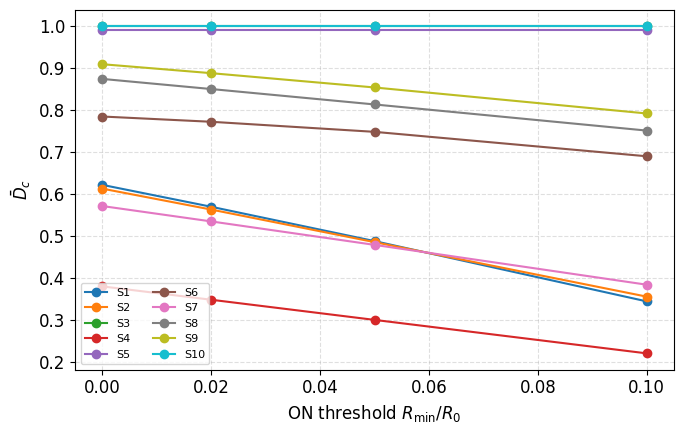

Rmin_frac  0.00  0.02  0.05  0.10
Scenario                         
S1        0.623 0.571 0.489 0.345
S2        0.614 0.564 0.486 0.357
S3        1.000 1.000 1.000 1.000
S4        0.381 0.349 0.301 0.222
S5        0.991 0.991 0.991 0.991
S6        0.785 0.773 0.749 0.691
S7        0.572 0.536 0.480 0.385
S8        0.875 0.851 0.814 0.752
S9        0.910 0.889 0.855 0.793
S10       1.000 1.000 1.000 1.000


In [11]:
fracs = [0.0, 0.02, 0.05, 0.10]
thr_rows = []
for s in SCEN:
    R0m = scenario_params[s]["R0_mean"]
    arr = res_curves[s]
    for f in fracs:
        thr_rows.append({"Scenario": s, "Rmin_frac": f,
                         "Dc": float((arr > f * R0m).mean())})
thr_df = pd.DataFrame(thr_rows)
thr_df.to_csv(tab_dir / "on_threshold.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
for s in SCEN:
    d = thr_df[thr_df.Scenario == s]
    ax.plot(d["Rmin_frac"], d["Dc"], marker="o", label=s)
ax.set_xlabel(r"ON threshold $R_{\min}/R_0$")
ax.set_ylabel(r"$\bar{D}_c$")
ax.grid(True, ls="--", alpha=0.4)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(fig_dir / "figureD_threshold.png", dpi=300, bbox_inches="tight")
plt.show()

pivt = thr_df.pivot(index="Scenario", columns="Rmin_frac", values="Dc").loc[SCEN]
print(pivt.to_string(float_format=lambda x: f"{x:.3f}"))
KEY["threshold_max_abs_Dc_change_5pct"] = round(float((pivt[0.05] - pivt[0.0]).abs().max()), 3)
KEY["threshold_max_abs_Dc_change_10pct"] = round(float((pivt[0.10] - pivt[0.0]).abs().max()), 3)

## 7. Global sensitivity analysis (LHS + PRCC) and two-parameter maps

For each collapse-prone scenario we draw 400 Latin Hypercube samples over
($r_f$, $\delta$, $r_d$, $h$, $c_f$) spanning the same global bounds used in the
one-at-a-time sweeps, run 25 hazard replicates per sample, and compute partial rank
correlation coefficients (PRCC) of $\bar{D}_c$ and $\bar{T}_c$ with respect to each
parameter. PRCC captures monotonic influence while controlling for simultaneous
variation of all other parameters. We then map the mean number of collapse cycles over
the ($r_f$, $\delta$) plane for every collapse-prone scenario, generalizing the S8
two-parameter analysis of Figure 2.

In [12]:
GSA_BOUNDS = {"rf": (0.05, 0.80), "delta": (0.1, 2.5), "rd": (5, 100),
              "h": (0.0, 0.005), "cf": (0.1, 1.0)}
PARAM_LABELS = {"rf": r"$r_f$", "delta": r"$\delta$", "rd": r"$r_d$",
                "h": r"$h$", "cf": r"$c_f$"}
N_LHS, N_REP_GSA = 400, 25


def lhs(n, k, rng):
    out = np.empty((n, k))
    for j in range(k):
        perm = rng.permutation(n)
        out[:, j] = (perm + rng.random(n)) / n
    return out


def prcc(X, y):
    Xr = np.apply_along_axis(rankdata, 0, X)
    yr = rankdata(y)
    n, k = X.shape
    out = np.empty(k)
    for i in range(k):
        A = np.column_stack([np.ones(n), np.delete(Xr, i, axis=1)])
        rx = Xr[:, i] - A @ np.linalg.lstsq(A, Xr[:, i], rcond=None)[0]
        ry = yr - A @ np.linalg.lstsq(A, yr, rcond=None)[0]
        out[i] = np.corrcoef(rx, ry)[0, 1]
    return out


rng_gsa = np.random.default_rng(42)
pnames = list(GSA_BOUNDS)
prcc_Dc, prcc_Tc = {}, {}
for s in COLLAPSE_PRONE:
    p = scenario_params[s]
    U = lhs(N_LHS, len(pnames), rng_gsa)
    X = np.empty_like(U)
    for j, name in enumerate(pnames):
        lo, hi = GSA_BOUNDS[name]
        X[:, j] = lo + U[:, j] * (hi - lo)
    yD = np.empty(N_LHS)
    yT = np.empty(N_LHS)
    for i in range(N_LHS):
        rf_, delta_, rd_, h_, cf_ = X[i, 0], X[i, 1], X[i, 2], X[i, 3], X[i, 4]
        Ds, Ts = [], []
        for _ in range(N_REP_GSA):
            _, _, L, C, D, _ = simulate(p["r"], p["R0_mean"], delta_, cf_, rd_, rf_,
                                        h_, rng_gsa, record=False)
            Ds.append(D); Ts.append(L)
        yD[i] = np.mean(Ds); yT[i] = np.mean(Ts)
    prcc_Dc[s] = prcc(X, yD)
    prcc_Tc[s] = prcc(X, yT)
    print(f"{s}: PRCC(Dc) = " + ", ".join(f"{n0}={v:+.2f}" for n0, v in zip(pnames, prcc_Dc[s])))

prcc_Dc_df = pd.DataFrame(prcc_Dc, index=pnames).T
prcc_Tc_df = pd.DataFrame(prcc_Tc, index=pnames).T
prcc_Dc_df.to_csv(tab_dir / "prcc_Dc.csv")
prcc_Tc_df.to_csv(tab_dir / "prcc_Tc.csv")

S1: PRCC(Dc) = rf=+0.76, delta=-0.84, rd=-0.84, h=-0.51, cf=-0.03


S2: PRCC(Dc) = rf=+0.69, delta=-0.78, rd=-0.83, h=-0.66, cf=-0.05


S4: PRCC(Dc) = rf=+0.68, delta=-0.80, rd=-0.85, h=-0.63, cf=-0.05


S6: PRCC(Dc) = rf=+0.51, delta=-0.48, rd=-0.86, h=-0.84, cf=-0.12


S7: PRCC(Dc) = rf=+0.74, delta=-0.81, rd=-0.84, h=-0.49, cf=-0.00


S8: PRCC(Dc) = rf=+0.71, delta=-0.75, rd=-0.87, h=-0.71, cf=-0.04


S9: PRCC(Dc) = rf=+0.58, delta=-0.70, rd=-0.84, h=-0.74, cf=+0.01


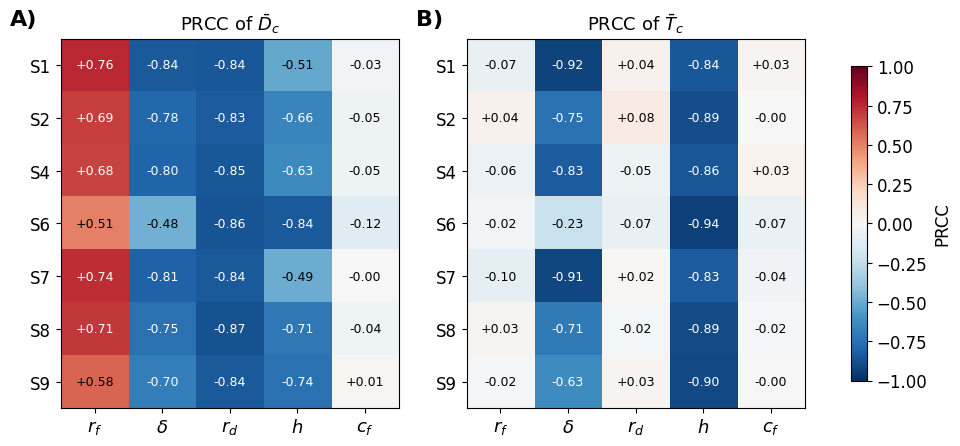

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4.8))
for ax, df_, title in [(axs[0], prcc_Dc_df, r"PRCC of $\bar{D}_c$"),
                       (axs[1], prcc_Tc_df, r"PRCC of $\bar{T}_c$")]:
    im = ax.imshow(df_.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
    ax.set_xticks(range(len(pnames)))
    ax.set_xticklabels([PARAM_LABELS[n0] for n0 in pnames], fontsize=13)
    ax.set_yticks(range(len(COLLAPSE_PRONE)))
    ax.set_yticklabels(COLLAPSE_PRONE)
    ax.set_title(title, fontsize=13)
    for i in range(df_.shape[0]):
        for j in range(df_.shape[1]):
            v = df_.values[i, j]
            ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=9,
                    color="white" if abs(v) > 0.6 else "black")
fig.colorbar(im, ax=axs, shrink=0.85, label="PRCC")
axs[0].text(-0.15, 1.08, "A)", transform=axs[0].transAxes, fontsize=16, fontweight="bold", va="top")
axs[1].text(-0.15, 1.08, "B)", transform=axs[1].transAxes, fontsize=16, fontweight="bold", va="top")
plt.savefig(fig_dir / "figure_gsa_prcc.png", dpi=300, bbox_inches="tight")
plt.show()

KEY["prcc_Dc_table"] = {s: {n0: round(float(v), 2) for n0, v in zip(pnames, prcc_Dc[s])}
                        for s in COLLAPSE_PRONE}

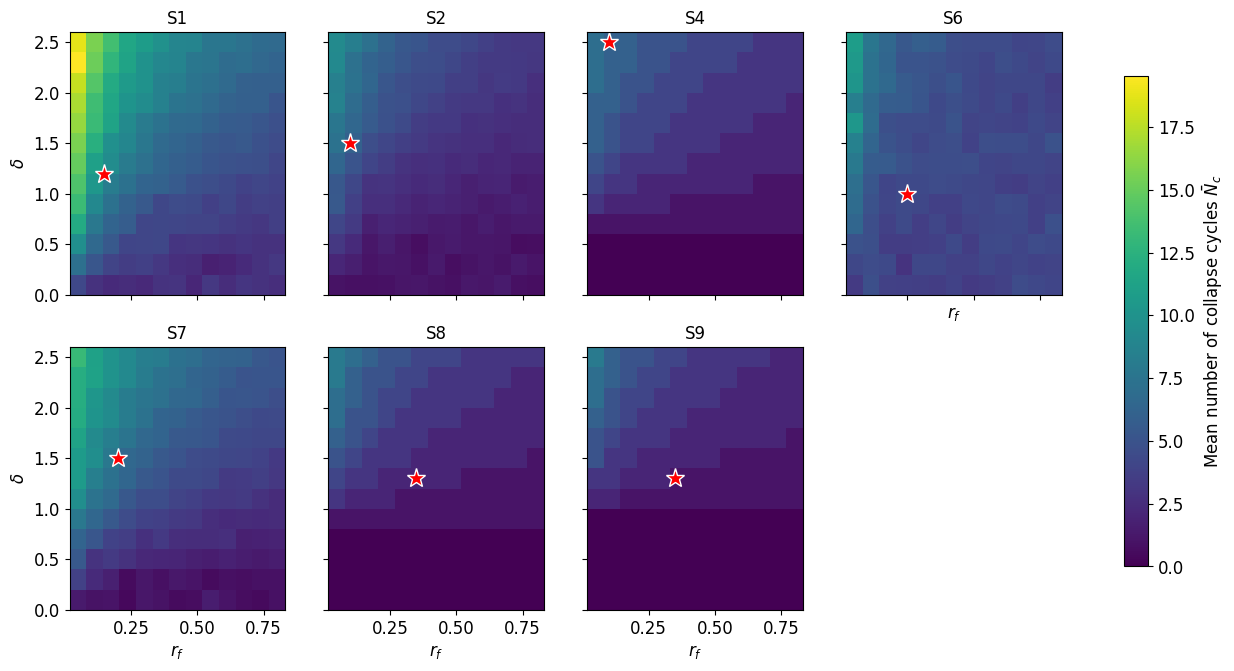

In [14]:
# Two-parameter (rf, delta) maps of mean collapse-cycle count for all collapse-prone scenarios
rf_grid = np.linspace(0.05, 0.8, 13)
delta_grid = np.linspace(0.1, 2.5, 13)
N_REP_MAP = 20
rng_map = np.random.default_rng(99)

fig, axs = plt.subplots(2, 4, figsize=(16, 7.5), sharex=True, sharey=True)
axs = axs.flatten()
vmax = 0
maps = {}
for s in COLLAPSE_PRONE:
    p = scenario_params[s]
    Z = np.empty((len(delta_grid), len(rf_grid)))
    for a, d_ in enumerate(delta_grid):
        for b, rf_ in enumerate(rf_grid):
            Cs = [simulate(p["r"], p["R0_mean"], d_, p["cf_mean"], p["rd_mean"], rf_,
                           p["h_ex_risk"], rng_map, record=False)[3]
                  for _ in range(N_REP_MAP)]
            Z[a, b] = np.mean(Cs)
    maps[s] = Z
    vmax = max(vmax, Z.max())
for ax, s in zip(axs, COLLAPSE_PRONE):
    p = scenario_params[s]
    im = ax.pcolormesh(rf_grid, delta_grid, maps[s], cmap="viridis", vmin=0, vmax=vmax,
                       shading="nearest")
    ax.plot(p["rf_mean"], p["delta_mean"], marker="*", color="red", ms=14, mec="white")
    ax.set_title(s, fontsize=12)
axs[-1].axis("off")
for i in [4, 5, 6]:
    axs[i].set_xlabel(r"$r_f$")
axs[3].set_xlabel(r"$r_f$")
for i in [0, 4]:
    axs[i].set_ylabel(r"$\delta$")
fig.colorbar(im, ax=axs, shrink=0.85, label=r"Mean number of collapse cycles $\bar{N}_c$")
plt.savefig(fig_dir / "figureE_2dmaps.png", dpi=300, bbox_inches="tight")
plt.show()

## 8. Growth-law invariance and technology coupling

**Invariance.** In the baseline model, technological capacity T(t) does not feed back
on resource dynamics, so all four outcome metrics (which are functionals of R(t) only)
are *exactly invariant* to the choice of growth law. We verify this numerically by
running identical seeds under linear, bounded-exponential, and logistic growth.

**Coupling.** We then break the decoupling deliberately, in two ways:
an *efficiency coupling* in which technology reduces the effective depletion rate,
$\delta_{\mathrm{eff}} = \delta / (1 + \gamma_\delta (T-1))$, and a *recovery coupling*
in which technology raises the post-collapse recovery fraction,
$r_{f,\mathrm{eff}} = \min[1, r_f (1 + \gamma_r (T-1))]$. We sweep the coupling
strengths and examine how the duty cycle and the scenario ranking respond.

In [15]:
inv_rows = []
for growth in ["linear", "exponential", "logistic"]:
    mg = run_mc(300, seed=555, growth=growth)
    for s in COLLAPSE_PRONE:
        m = mg[s]
        inv_rows.append({"Growth": growth, "Scenario": s, "Dc": m["Dc"].mean(),
                         "Tc": m["Tc"].mean(), "Nc": m["Nc"].mean()})
inv_df = pd.DataFrame(inv_rows)
inv_piv = inv_df.pivot(index="Scenario", columns="Growth", values="Dc").loc[COLLAPSE_PRONE]
print("Mean duty cycle under different growth laws (identical seeds):")
print(inv_piv.to_string(float_format=lambda x: f"{x:.4f}"))
assert np.allclose(inv_piv["linear"], inv_piv["exponential"]) and \
       np.allclose(inv_piv["linear"], inv_piv["logistic"]), "Growth-law invariance violated"
print("\nAll metrics are exactly invariant to the growth law in the baseline (uncoupled) model.")
KEY["growth_invariance_confirmed"] = True

Mean duty cycle under different growth laws (identical seeds):
Growth    exponential  linear  logistic
Scenario                               
S1             0.6336  0.6336    0.6336
S2             0.6114  0.6114    0.6114
S4             0.3803  0.3803    0.3803
S6             0.7965  0.7965    0.7965
S7             0.5760  0.5760    0.5760
S8             0.8721  0.8721    0.8721
S9             0.9110  0.9110    0.9110

All metrics are exactly invariant to the growth law in the baseline (uncoupled) model.


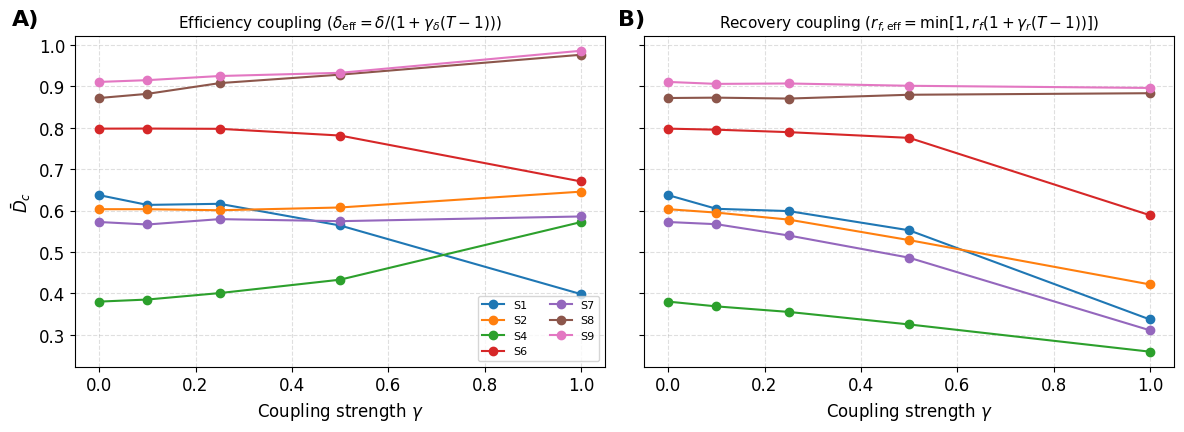

Duty cycle vs efficiency-coupling strength:
gamma     0.00  0.10  0.25  0.50  1.00
Scenario                              
S1       0.637 0.614 0.616 0.564 0.398
S2       0.603 0.603 0.601 0.608 0.646
S4       0.380 0.385 0.401 0.433 0.572
S6       0.798 0.798 0.798 0.781 0.671
S7       0.572 0.566 0.579 0.575 0.586
S8       0.872 0.882 0.908 0.928 0.977
S9       0.911 0.915 0.925 0.933 0.986

Duty cycle vs recovery-coupling strength:
gamma     0.00  0.10  0.25  0.50  1.00
Scenario                              
S1       0.637 0.604 0.599 0.552 0.337
S2       0.603 0.595 0.578 0.529 0.422
S4       0.380 0.369 0.355 0.325 0.259
S6       0.798 0.796 0.790 0.776 0.589
S7       0.572 0.567 0.540 0.486 0.311
S8       0.872 0.873 0.871 0.880 0.884
S9       0.911 0.906 0.907 0.902 0.896


In [16]:
gammas = [0.0, 0.1, 0.25, 0.5, 1.0]
N_REP_CPL = 200
cpl_rows = []
for mode, kw in [("efficiency", "gamma_delta"), ("recovery", "gamma_rf")]:
    for g in gammas:
        mg = run_mc(N_REP_CPL, seed=888, **{kw: g})
        for s in COLLAPSE_PRONE:
            cpl_rows.append({"Mode": mode, "gamma": g, "Scenario": s,
                             "Dc": mg[s]["Dc"].mean(), "Nc": mg[s]["Nc"].mean()})
cpl_df = pd.DataFrame(cpl_rows)
cpl_df.to_csv(tab_dir / "coupling.csv", index=False)

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, mode, title in [(axs[0], "efficiency", r"Efficiency coupling ($\delta_{\rm eff}=\delta/(1+\gamma_\delta(T-1))$)"),
                        (axs[1], "recovery", r"Recovery coupling ($r_{f,{\rm eff}}=\min[1,r_f(1+\gamma_r(T-1))]$)")]:
    for s in COLLAPSE_PRONE:
        d = cpl_df[(cpl_df.Mode == mode) & (cpl_df.Scenario == s)]
        ax.plot(d["gamma"], d["Dc"], marker="o", label=s)
    ax.set_xlabel(r"Coupling strength $\gamma$")
    ax.set_title(title, fontsize=11)
    ax.grid(True, ls="--", alpha=0.4)
axs[0].set_ylabel(r"$\bar{D}_c$")
axs[0].legend(fontsize=8, ncol=2)
axs[0].text(-0.12, 1.08, "A)", transform=axs[0].transAxes, fontsize=16, fontweight="bold", va="top")
axs[1].text(-0.05, 1.08, "B)", transform=axs[1].transAxes, fontsize=16, fontweight="bold", va="top")
plt.tight_layout()
plt.savefig(fig_dir / "figureF_coupling.png", dpi=300, bbox_inches="tight")
plt.show()

base_rank = cpl_df[(cpl_df.Mode == "efficiency") & (cpl_df.gamma == 0.0)].set_index("Scenario")["Dc"].rank()
for mode in ["efficiency", "recovery"]:
    for g in gammas[1:]:
        rank_g = cpl_df[(cpl_df.Mode == mode) & (cpl_df.gamma == g)].set_index("Scenario")["Dc"].rank()
        tau = np.corrcoef(base_rank.loc[COLLAPSE_PRONE], rank_g.loc[COLLAPSE_PRONE])[0, 1]
        KEY[f"coupling_{mode}_g{g}_rankcorr"] = round(float(tau), 3)
piv_eff = cpl_df[cpl_df.Mode == "efficiency"].pivot(index="Scenario", columns="gamma", values="Dc").loc[COLLAPSE_PRONE]
piv_rec = cpl_df[cpl_df.Mode == "recovery"].pivot(index="Scenario", columns="gamma", values="Dc").loc[COLLAPSE_PRONE]
print("Duty cycle vs efficiency-coupling strength:")
print(piv_eff.to_string(float_format=lambda x: f"{x:.3f}"))
print("\nDuty cycle vs recovery-coupling strength:")
print(piv_rec.to_string(float_format=lambda x: f"{x:.3f}"))
KEY["coupling_eff_max_Dc_gain_g05"] = round(float((piv_eff[0.5] - piv_eff[0.0]).max()), 3)
KEY["coupling_rec_max_Dc_gain_g05"] = round(float((piv_rec[0.5] - piv_rec[0.0]).max()), 3)

## 9. Regenerated main-text figures (N = 1000 baseline)

Figures 3 (summary metrics) and 6 (technosignature observation probabilities) of the
manuscript, regenerated from the baseline ensemble. Note: an earlier
version of Figure 6 mistakenly titled panel C "CFC-11"; it shows CFC-12 and is
corrected here.

/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_59100/3294401478.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=0, ha="center")
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_59100/3294401478.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=0, ha="center")
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_59100/3294401478.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=0, ha="center")
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_59100/3294401478.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or u

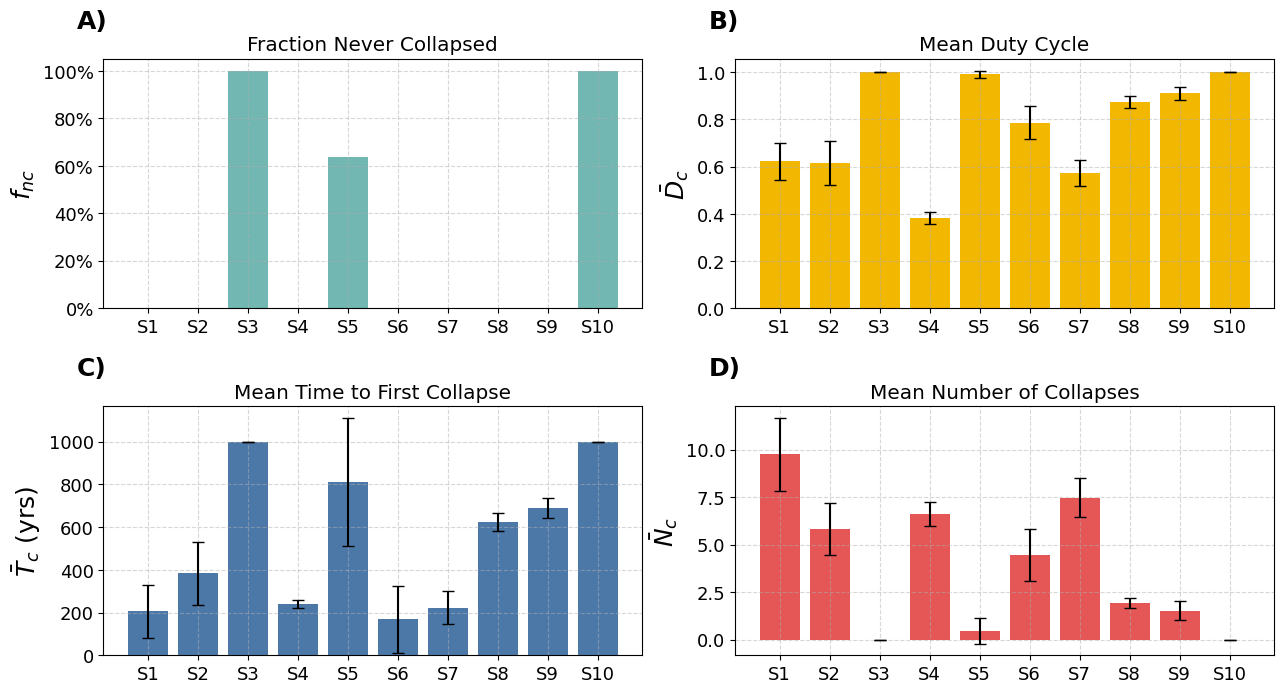

In [17]:
import matplotlib.ticker as mtick

df = summary.copy()
df["Label"] = df["Scenario"]
colors4 = ["#72B7B2", "#F2B701", "#4C78A8", "#E45756"]

fig, axs = plt.subplots(2, 2, figsize=(13, 7.5))
axs = axs.flatten()
panel_labels = ["A)", "B)", "C)", "D)"]
axs[0].bar(df["Label"], df["fnc"], color=colors4[0])
axs[0].set_ylabel(r"$f_{nc}$", fontsize=18)
axs[0].set_title("Fraction Never Collapsed")
axs[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
axs[1].bar(df["Label"], df["Dc_mean"], yerr=df["Dc_std"], capsize=4, color=colors4[1])
axs[1].set_ylabel(r"$\bar{D}_{c}$", fontsize=18)
axs[1].set_title("Mean Duty Cycle")
axs[2].bar(df["Label"], df["Tc_mean"], yerr=df["Tc_std"], capsize=4, color=colors4[2])
axs[2].set_ylabel(r"$\bar{T}_{c}$ (yrs)", fontsize=18)
axs[2].set_title("Mean Time to First Collapse")
axs[3].bar(df["Label"], df["Nc_mean"], yerr=df["Nc_std"], capsize=4, color=colors4[3])
axs[3].set_ylabel(r"$\bar{N}_{c}$", fontsize=18)
axs[3].set_title("Mean Number of Collapses")
for ax, label in zip(axs, panel_labels):
    ax.set_xticklabels(df["Label"], rotation=0, ha="center")
    ax.tick_params(labelsize=13)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.text(-0.05, 1.2, label, transform=ax.transAxes, fontsize=18, fontweight="bold",
            va="top", ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(fig_dir / "figure3.png", dpi=300, bbox_inches="tight")
plt.show()

/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_59100/1755473831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=0, ha="center")
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_59100/1755473831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=0, ha="center")
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_59100/1755473831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df["Label"], rotation=0, ha="center")
/var/folders/38/2zkx65c923d5y4297z_j_w0r0000gn/T/ipykernel_59100/1755473831.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or u

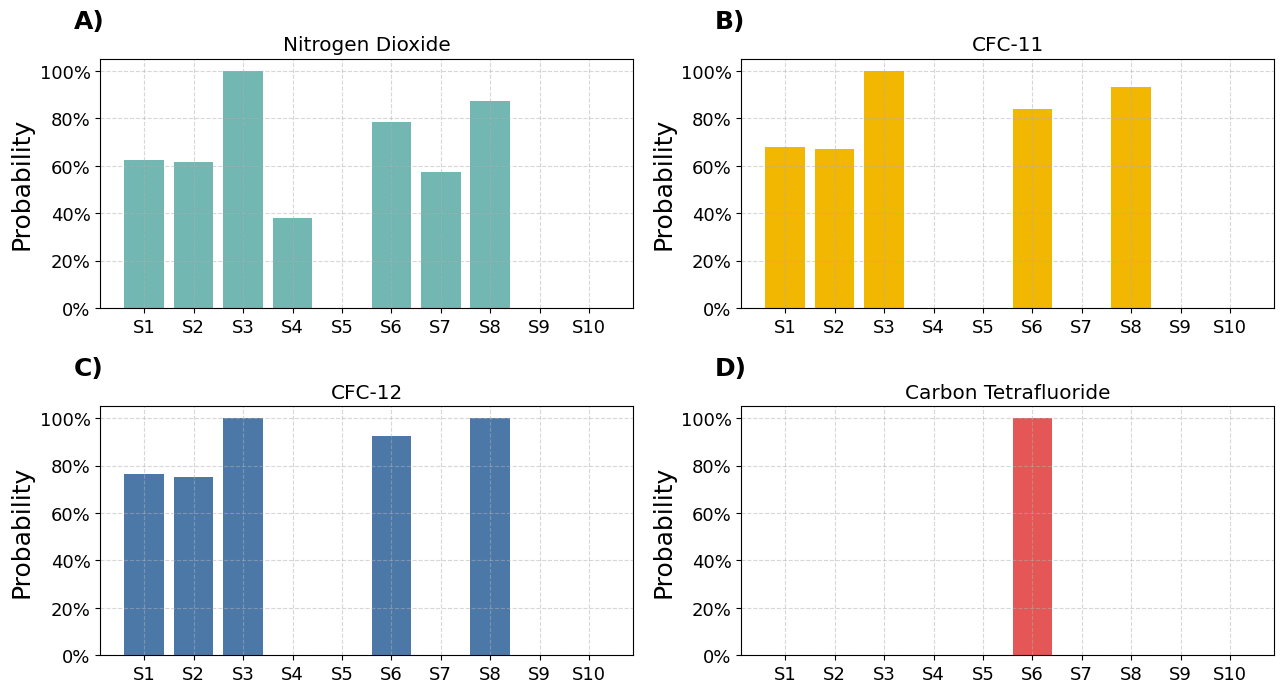

In [18]:
ts_panels = [
    ("Nitrogen Dioxide", 0.0,   [1, 1, 1, 1, 0, 1, 1, 1, 0, 0]),
    ("CFC-11",           55.0,  [1, 1, 1, 0, 0, 1, 0, 1, 0, 0]),
    ("CFC-12",           140.0, [1, 1, 1, 0, 0, 1, 0, 1, 0, 0]),
    ("Carbon Tetrafluoride", 1000.0, [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]),
]
fig, axs = plt.subplots(2, 2, figsize=(13, 7.5))
axs = axs.flatten()
for ax, label, (title, lifetime, present), c in zip(axs, panel_labels, ts_panels, colors4):
    prob = (df["Dc_mean"] + np.minimum(lifetime / 1000.0, 1.0 - df["Dc_mean"])) * np.array(present)
    ax.bar(df["Label"], prob, color=c)
    ax.set_ylabel("Probability", fontsize=18)
    ax.set_title(title)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    ax.set_xticklabels(df["Label"], rotation=0, ha="center")
    ax.tick_params(labelsize=13)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.text(-0.05, 1.2, label, transform=ax.transAxes, fontsize=18, fontweight="bold",
            va="top", ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig(fig_dir / "figure6.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Export key numbers

In [19]:
with open(tab_dir / "key_numbers.json", "w") as f:
    json.dump(KEY, f, indent=2)
print(json.dumps(KEY, indent=2))

{
  "S1_Dc": 0.623,
  "S1_Tc": 205.8,
  "S1_Nc": 9.76,
  "S1_fnc": 0.0,
  "S1_hazardfrac": 0.202,
  "S2_Dc": 0.614,
  "S2_Tc": 383.2,
  "S2_Nc": 5.84,
  "S2_fnc": 0.0,
  "S2_hazardfrac": 0.097,
  "S3_Dc": 1.0,
  "S3_Tc": 1000.0,
  "S3_Nc": 0.0,
  "S3_fnc": 1.0,
  "S3_hazardfrac": null,
  "S4_Dc": 0.381,
  "S4_Tc": 240.6,
  "S4_Nc": 6.6,
  "S4_fnc": 0.0,
  "S4_hazardfrac": 0.0,
  "S5_Dc": 0.991,
  "S5_Tc": 810.6,
  "S5_Nc": 0.45,
  "S5_fnc": 0.635,
  "S5_hazardfrac": 1.0,
  "S6_Dc": 0.785,
  "S6_Tc": 169.5,
  "S6_Nc": 4.46,
  "S6_fnc": 0.0,
  "S6_hazardfrac": 0.925,
  "S7_Dc": 0.572,
  "S7_Tc": 223.3,
  "S7_Nc": 7.47,
  "S7_fnc": 0.0,
  "S7_hazardfrac": 0.087,
  "S8_Dc": 0.875,
  "S8_Tc": 623.5,
  "S8_Nc": 1.94,
  "S8_fnc": 0.0,
  "S8_hazardfrac": 0.0,
  "S9_Dc": 0.91,
  "S9_Tc": 689.2,
  "S9_Nc": 1.52,
  "S9_fnc": 0.0,
  "S9_hazardfrac": 0.0,
  "S10_Dc": 1.0,
  "S10_Tc": 1000.0,
  "S10_Nc": 0.0,
  "S10_fnc": 1.0,
  "S10_hazardfrac": null,
  "conv_max_rel_dev_200": 0.3636,
  "conv_max_r